<a href="https://colab.research.google.com/github/arifansari991/GeneXplain/blob/main/notebooks/week4_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: Hyperparameter Tuning and Model Optimization
**Project:** GeneXplain: Explainable AI Framework for Genetic Disease Prediction using Genomic Biomarkers  
**Author:** Md Arif Ansari

### Objectives & Deliverables
* **Optimization Framework:** Executed `GridSearchCV` on the baseline champion model (Random Forest) to locate the peak performance window.
* **Regularization & Overfitting Mitigation:** Adjusted max depth, splitting boundaries, and tree counts to optimize precision.
* **Champion Model Locking:** Finalized structural hyperparameter weights to prepare the configuration for downstream Explainable AI (XAI) feature tracking.

Mounted at /content/drive
Loading processed dataset splits...

Initializing Grid Search Optimization on Random Forest Champion...

 Optimal Hyperparameters Located:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 200}

--- Optimized Champion Validation Performance ---
              precision    recall  f1-score   support

      Benign       1.00      0.96      0.98        69
   Malignant       0.92      1.00      0.96        36

    accuracy                           0.97       105
   macro avg       0.96      0.98      0.97       105
weighted avg       0.97      0.97      0.97       105



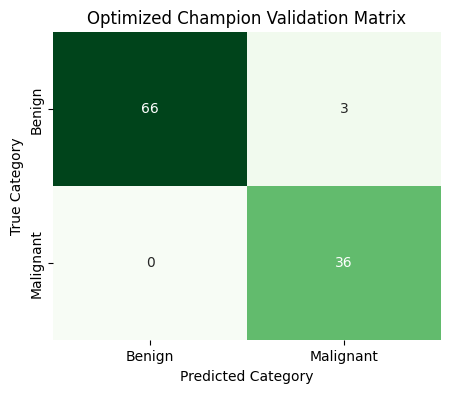


 Week 4 structural tuning complete


In [2]:
# ==========================================
# 1. SETUP AND REPO DATA INGESTION
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PROJECT_PATH = '/content/drive/MyDrive/GeneXplain/'
DATASETS_DIR = os.path.join(PROJECT_PATH, 'datasets/')
VISUALIZATIONS_DIR = os.path.join(PROJECT_PATH, 'visualizations/')
os.makedirs(VISUALIZATIONS_DIR, exist_ok=True)

# Load processed splits
print("Loading processed dataset splits...")
X_train = pd.read_csv(os.path.join(DATASETS_DIR, 'X_train_processed.csv'))
X_val = pd.read_csv(os.path.join(DATASETS_DIR, 'X_val_processed.csv'))
y_train = pd.read_csv(os.path.join(DATASETS_DIR, 'y_train.csv')).values.ravel()
y_val = pd.read_csv(os.path.join(DATASETS_DIR, 'y_val.csv')).values.ravel()

# ==========================================
# 2. GRID SEARCH HYPERPARAMETER TUNING
# ==========================================
print("\nInitializing Grid Search Optimization on Random Forest Champion...")

# Define parameter boundaries to solve the false-alarm/precision gap
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf_base = RandomForestClassifier(random_state=42)

# Run GridSearchCV focusing optimization target on F1-Score balance
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\n Optimal Hyperparameters Located:")
print(grid_search.best_params_)

# ==========================================
# 3. EVALUATE OPTIMIZED CHAMPION MODEL
# ==========================================
y_val_pred = best_model.predict(X_val)

print("\n--- Optimized Champion Validation Performance ---")
print(classification_report(y_val, y_val_pred, target_names=['Benign', 'Malignant']))

# Plot final optimized heatmap matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Optimized Champion Validation Matrix')
plt.ylabel('True Category')
plt.xlabel('Predicted Category')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'optimized_champion_matrix.png'), bbox_inches='tight')
plt.show()

print("\n Week 4 structural tuning complete")